In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

<h3>Fashion MNIST data</h3>

In [2]:
# Fashion MNIST data

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

100.0%
100.0%
100.0%
100.0%


In [3]:
train_loader = DataLoader(dataset=train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=64, shuffle=True)

In [4]:
print('Size of image :', train_data.data[0].shape)

Size of image : torch.Size([28, 28])


In [5]:
inputDim = 28*28
layerDim = 300
latentDim = 20

In [6]:
class VAE(nn.Module):

    def __init__(self):
        super().__init__()
        self.layerDim = layerDim
        self.latentDim = latentDim

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(inputDim, self.layerDim), # input layer to hidden layer
            nn.ReLU(),
            nn.Linear(self.layerDim, self.layerDim), # hidden layer to latent dimension
            nn.ReLU()
        )

        self.mean = nn.Linear(self.layerDim, self.latentDim) # get mean of latent distribution
        self.logvar = nn.Linear(self.layerDim, self.latentDim) # get log variance of latent distribution

        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(self.latentDim, self.layerDim), # latent dimension to hidden layer
            nn.ReLU(),
            nn.Linear(self.layerDim, self.layerDim),
            nn.ReLU(),
            nn.Linear(self.layerDim, inputDim), # hidden layer to original space
            nn.Sigmoid()
        )

    def reparametrize(self, mean, logvar):
        sd = torch.exp(0.5*logvar)
        eps = torch.randn_like(sd)
        return mean + eps*sd

    def forward(self, x):
        x = x.view(-1, inputDim)
        encoded = self.encoder(x) # encoded input
        mean_ = self.mean(encoded)
        logvariance_ = self.logvar(encoded)
        z = self.reparametrize(mean=mean_, logvar=logvariance_)
        decoded = self.decoder(z) # decoder output
        return decoded, mean_, logvariance_

    # generate new samples
    def sample(self, numSamples):
        with torch.no_grad():
            z = torch.randn(numSamples, self.latentDim)
            samples = self.decoder(z)
        return samples

<h3>Display some images</h3>

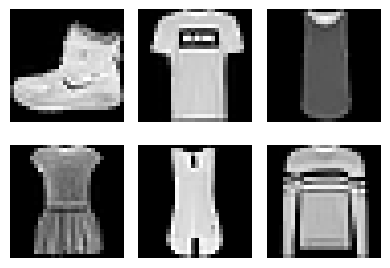

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(4,3))
axes = axes.flatten()

for i in range(6):
    img = train_data.data[i]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off') # removes X and Y axis

plt.tight_layout()
plt.show()

In [8]:
vae = VAE()
optimizer = optim.Adam(vae.parameters(), lr=1e-4)
epochs = 20
vae.train()

for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        decoded, mu, log_var = vae(x)
        
        # Reconstruction loss
        recon_loss = nn.functional.binary_cross_entropy(decoded, x.view(-1, 784), reduction="sum")
        
        # KL divergence
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        
        loss = recon_loss + kl_loss
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / x.size(0)
    print('Completed epoch', epoch)

Completed epoch 0
Completed epoch 1
Completed epoch 2
Completed epoch 3
Completed epoch 4
Completed epoch 5
Completed epoch 6
Completed epoch 7
Completed epoch 8
Completed epoch 9
Completed epoch 10
Completed epoch 11
Completed epoch 12
Completed epoch 13
Completed epoch 14
Completed epoch 15
Completed epoch 16
Completed epoch 17
Completed epoch 18
Completed epoch 19


<h3>Compare original and reconstructed</h3>

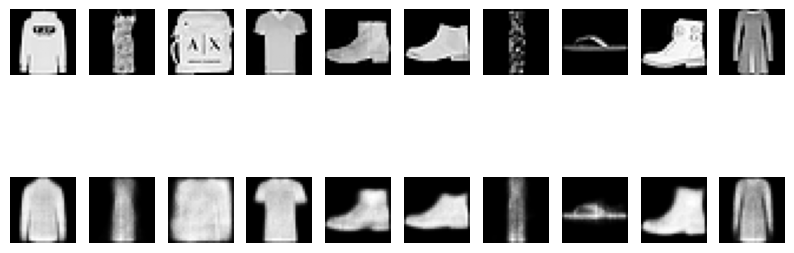

In [10]:
vae.eval()
x, _ = next(iter(test_loader))
x = x.view(-1, 784)
decoded, mu, var = vae(x)

# Compare original and reconstructed images
plt.figure(figsize=(10, 4))
for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x[i].view(28, 28), cmap='gray')
    plt.axis('off')
    
    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(decoded[i].view(28, 28).detach(), cmap='gray')
    plt.axis('off')

plt.show()